In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np


In [2]:
#Set paths
project_root = Path.cwd().parent
data_raw = project_root / "data" / "raw"
data_processed = project_root / "data" / "processed"

print("Project root:", project_root)
print("Raw data folder:", data_raw)
print("Processed data folder:", data_processed)

Project root: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection
Raw data folder: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\raw
Processed data folder: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\processed


In [6]:
for path in data_raw.rglob("*"):
    print(path)

c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\raw\enron_emails.csv
c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\raw\phishing_emails.csv


In [7]:
ham_df = pd.read_csv(data_raw / "enron_emails.csv")
phish_df = pd.read_csv(data_raw / "phishing_emails.csv")

print("Ham shape:", ham_df.shape)
print("Phishing shape:", phish_df.shape)

Ham shape: (517401, 2)
Phishing shape: (82486, 2)


In [10]:
ham_df.head()
# phish_df.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [9]:
print("Ham columns:", list(ham_df.columns))
print("Phishing columns:", list(phish_df.columns))

Ham columns: ['file', 'message']
Phishing columns: ['text_combined', 'label']


In [ ]:
#Standardize the ham dataframe.
ham_df = ham_df.rename(columns={"message": "text"}).copy()
ham_df["label"] = 0
ham_df = ham_df[["text", "label"]]

print(ham_df.head())
print(ham_df.columns)
print(ham_df["label"].value_counts())

                                                text  label
0  Message-ID: <18782981.1075855378110.JavaMail.e...      0
1  Message-ID: <15464986.1075855378456.JavaMail.e...      0
2  Message-ID: <24216240.1075855687451.JavaMail.e...      0
3  Message-ID: <13505866.1075863688222.JavaMail.e...      0
4  Message-ID: <30922949.1075863688243.JavaMail.e...      0
Index(['text', 'label'], dtype='object')
label
0    517401
Name: count, dtype: int64


In [14]:
#Standardize the phishing dataframe.
phish_df = phish_df.rename(columns={"text_combined": "text"}).copy()
phish_df = phish_df[["text", "label"]]

print(phish_df.head())
print(phish_df.columns)
print(phish_df["label"].value_counts())

                                                text  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0
3  hpl nom may 30 2001 see attached file hplno 53...      0
4  hpl nom june 1 2001 see attached file hplno 60...      0
Index(['text', 'label'], dtype='object')
label
1    42891
0    39595
Name: count, dtype: int64


In [15]:
print(phish_df["label"].unique())
print(phish_df["label"].value_counts())

[0 1]
label
1    42891
0    39595
Name: count, dtype: int64


In [16]:
#Inspect sample emails from each label
print("Sample label 0:\n")
print(phish_df[phish_df["label"] == 0]["text"].iloc[0][:1500])

print("\n" + "="*80 + "\n")

print("Sample label 1:\n")
print(phish_df[phish_df["label"] == 1]["text"].iloc[0][:1500])

Sample label 0:

hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


Sample label 1:

link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz frequency g 510 features 802 11 g standard backwards compatible existing 802 11 11 b products already also offers 64 128 bit wep encryption includes removable antenna driver cd get link g 510 wireless pci lan adapter today general features pci interface removable antenna 64 128 bit wep encryption link act led plug play one stop distributorjebel ali duty free zonedubai uae www computron com latest cl

In [17]:
#Create the working dataset from phish_df

working_df = phish_df.copy()

working_df["text"] = working_df["text"].fillna("").astype(str)
working_df = working_df[working_df["text"].str.strip() != ""].drop_duplicates().copy()

print("Working dataset shape:", working_df.shape)
print(working_df["label"].value_counts())
working_df.head()

Working dataset shape: (82077, 2)
label
1    42844
0    39233
Name: count, dtype: int64


,text,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [18]:
#Save the working dataset to the processed data folder
output_path = data_processed / "combined_raw_emails.csv"
working_df.to_csv(output_path, index=False)
print("Saved to:", output_path)

Saved to: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\processed\combined_raw_emails.csv


Matplotlib is building the font cache; this may take a moment.


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,39233.0,1541.456147,3711.537111,11.0,411.0,780.0,1495.0,160318.0
1,42844.0,1060.717253,21204.284590,3.0,241.0,391.0,1058.0,4279526.0


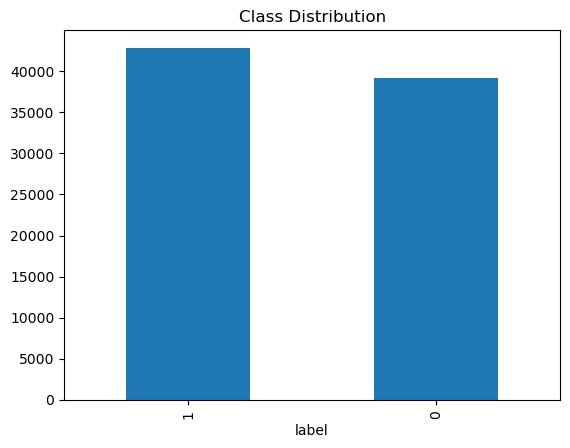

In [19]:
#Class distribution
working_df["label"].value_counts().plot(kind="bar", title="Class Distribution")
# Text length statistics
working_df["text_length"] = working_df["text"].str.len()
working_df.groupby("label")["text_length"].describe()




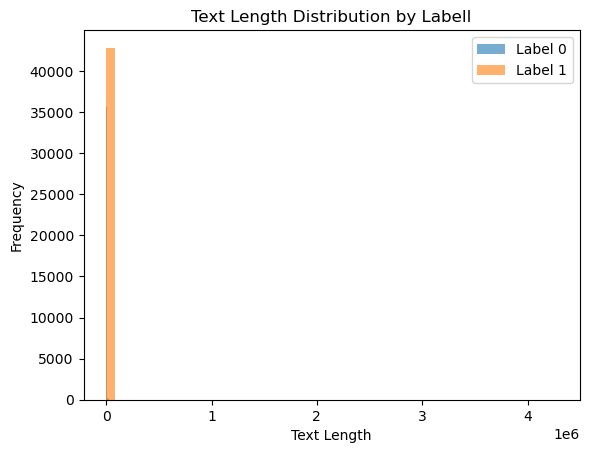

In [25]:
# Plot text length by label
import matplotlib.pyplot as plt

working_df[working_df["label"] == 0]["text_length"].plot(
    kind="hist", bins=50, alpha=0.6, label="Label 0"
)
working_df[working_df["label"] == 1]["text_length"].plot(
    kind="hist", bins=50, alpha=0.6, label="Label 1"
)

plt.legend()
plt.title("Text Length Distribution by Labell")
plt.xlabel("Text Length")
plt.show()

In [24]:
print("Sample label 0:\n")
print(phish_df[phish_df["label"] == 0]["text"].iloc[0][:1500])

print("\n" + "="*80 + "\n")

print("Sample label 1:\n")
print(phish_df[phish_df["label"] == 1]["text"].iloc[0][:1500])

Sample label 0:

hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


Sample label 1:

link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz frequency g 510 features 802 11 g standard backwards compatible existing 802 11 11 b products already also offers 64 128 bit wep encryption includes removable antenna driver cd get link g 510 wireless pci lan adapter today general features pci interface removable antenna 64 128 bit wep encryption link act led plug play one stop distributorjebel ali duty free zonedubai uae www computron com latest cl